**Project Title**

Predicting Student Dropout Risk Using Traditional Machine Learning and Deep Learning Approaches

**My Research Question**

Can machine learning and deep learning models accurately predict whether a student will Drop Out, Enroll, or Graduate based on demographic, socioeconomic, and academic performance indicators?

**Student Dropout Prediction Using Machine Learning and Deep Learning**

This project investigates whether student dropout risk can be predicted using demographic, academic, and socioeconomic indicators.

The objective is to compare traditional machine learning models implemented using Scikit-Learn against deep learning models implemented using TensorFlow.

The final target variable contains three classes:

- Dropout
- Enrolled
- Graduate

The results will help determine which modeling approach is most suitable for early student intervention programs.

**Importing Required Libraries**

This section imports all libraries needed for data manipulation,
visualization, preprocessing, machine learning, deep learning,
and model evaluation.

The imported libraries are grouped according to their purpose
to improve readability and maintainability of the notebook.

In [20]:
# BASIC LIBRARIES

import numpy as np
import pandas as pd


# VISUALIZATION

import matplotlib.pyplot as plt
import seaborn as sns


# SCIKIT-LEARN

from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    StratifiedKFold
)

from sklearn.preprocessing import (
    StandardScaler,
    LabelEncoder
)

from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)

from sklearn.linear_model import LogisticRegression

from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier
)

from sklearn.svm import SVC

# TENSORFLOW

import tensorflow as tf

from tensorflow.keras.models import Model
from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import (
    Dense,
    Dropout,
    BatchNormalization,
    Input
)

from tensorflow.keras.callbacks import (
    EarlyStopping
)


# REPRODUCIBILITY

np.random.seed(42)
tf.random.set_seed(42)

print("Libraries Loaded Successfully")

Libraries Loaded Successfully


**Loading the Dataset**

The dataset is loaded into a Pandas DataFrame.

After loading, the first few records are displayed to verify
successful import.

In [21]:
df = pd.read_csv("dataset.csv")

df.head()

,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Nacionality,Mother's qualification,Father's qualification,Mother's occupation,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,8,5,2,1,1,1,13,10,6,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,6,1,11,1,1,1,1,3,4,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,5,1,1,1,22,27,10,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,8,2,15,1,1,1,23,27,6,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,12,1,3,0,1,1,22,28,10,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


**Dataset Inspection**

Before training models, it is important to understand:

- Number of observations
- Number of features
- Data types
- Missing values
- Statistical summaries

To help me identify preprocessing requirements.

In [22]:
print("Shape:")
print(df.shape)

print("\n")

print("Information:")
print(df.info())

print("\n")

display(df.describe())

Shape:
(4424, 35)


Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 35 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Marital status                                  4424 non-null   int64  
 1   Application mode                                4424 non-null   int64  
 2   Application order                               4424 non-null   int64  
 3   Course                                          4424 non-null   int64  
 4   Daytime/evening attendance                      4424 non-null   int64  
 5   Previous qualification                          4424 non-null   int64  
 6   Nacionality                                     4424 non-null   int64  
 7   Mother's qualification                          4424 non-null   int64  
 8   Father's qualification                          4424 non-null   int64  
 9   Mother's

,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Nacionality,Mother's qualification,Father's qualification,Mother's occupation,...,Curricular units 1st sem (without evaluations),Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP
count,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,...,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000
mean,1.178571,6.886980,1.727848,9.899186,0.890823,2.531420,1.254521,12.322107,16.455244,7.317812,...,0.137658,0.541817,6.232143,8.063291,4.435805,10.230206,0.150316,11.566139,1.228029,0.001969
std,0.605747,5.298964,1.313793,4.331792,0.311897,3.963707,1.748447,9.026251,11.044800,3.997828,...,0.690880,1.918546,2.195951,3.947951,3.014764,5.210808,0.753774,2.663850,1.382711,2.269935
min,1.000000,1.000000,0.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,7.600000,-0.800000,-4.060000
25%,1.000000,1.000000,1.000000,6.000000,1.000000,1.000000,1.000000,2.000000,3.000000,5.000000,...,0.000000,0.000000,5.000000,6.000000,2.000000,10.750000,0.000000,9.400000,0.300000,-1.700000
50%,1.000000,8.000000,1.000000,10.000000,1.000000,1.000000,1.000000,13.000000,14.000000,6.000000,...,0.000000,0.000000,6.000000,8.000000,5.000000,12.200000,0.000000,11.100000,1.400000,0.320000
75%,1.000000,12.000000,2.000000,13.000000,1.000000,1.000000,1.000000,22.000000,27.000000,10.000000,...,0.000000,0.000000,7.000000,10.000000,6.000000,13.333333,0.000000,13.900000,2.600000,1.790000
max,6.000000,18.000000,9.000000,17.000000,1.000000,17.000000,21.000000,29.000000,34.000000,32.000000,...,12.000000,19.000000,23.000000,33.000000,20.000000,18.571429,12.000000,16.200000,3.700000,3.510000


**Target Variable Distribution**

Understanding class distribution is important because
imbalanced datasets can affect model performance.

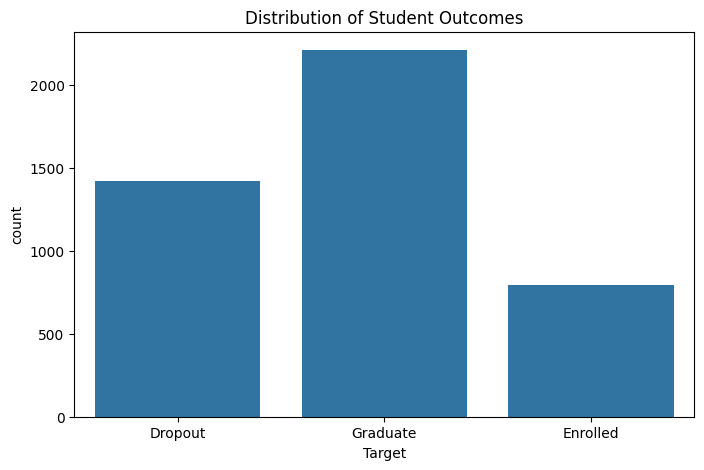

In [23]:
plt.figure(figsize=(8,5))

sns.countplot(
    x='Target',
    data=df
)

plt.title("Distribution of Student Outcomes")
plt.show()

**Missing Value Analysis**

Missing values can negatively affect machine learning models.

This section checks whether any variables contain missing observations.

In [24]:
missing_values = df.isnull().sum()

missing_values[missing_values > 0]

,0


**Feature Correlation Analysis**

Correlation analysis helps identify relationships
between numerical features and potential multicollinearity.

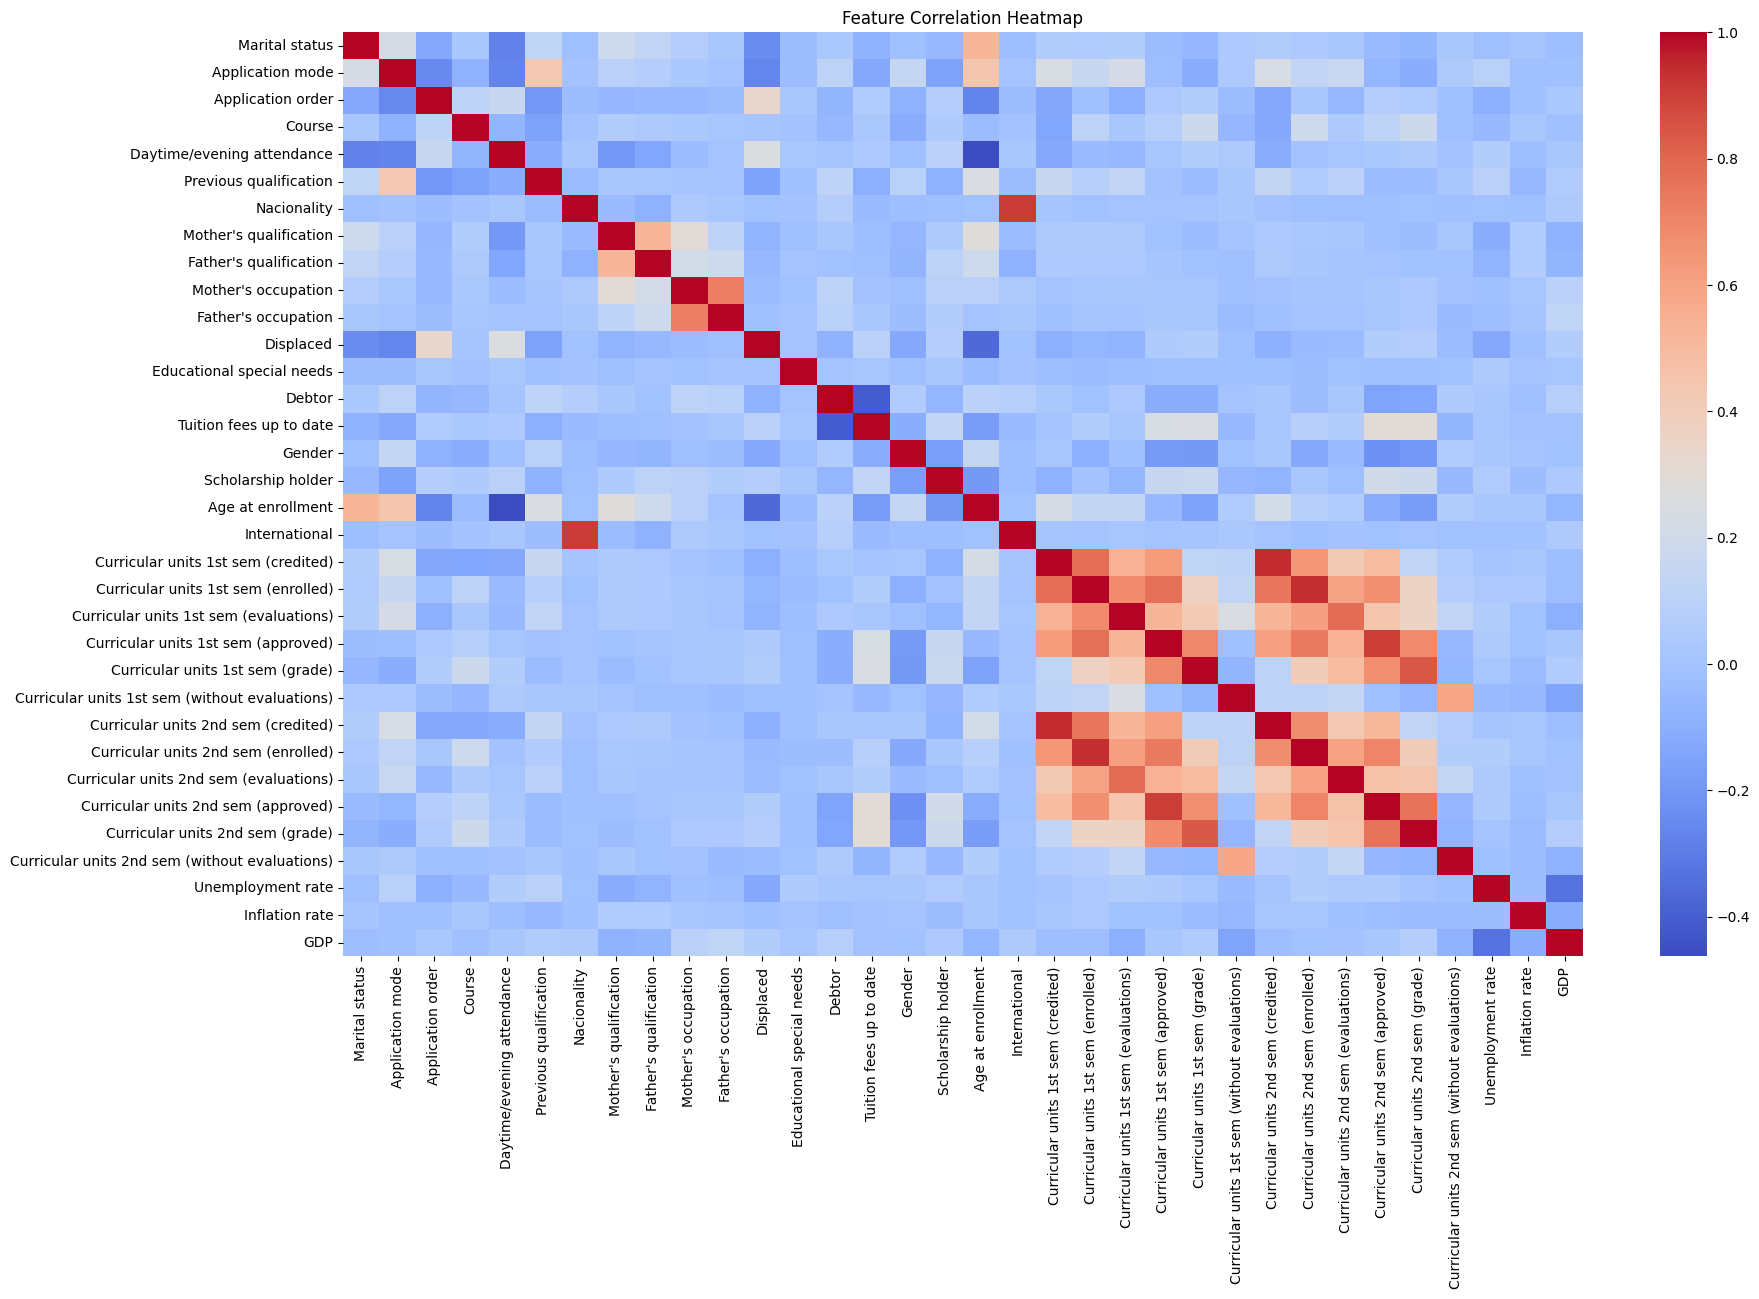

In [25]:
plt.figure(figsize=(20,12))

sns.heatmap(
    df.select_dtypes(include=np.number).corr(),
    cmap='coolwarm'
)

plt.title("Feature Correlation Heatmap")

plt.show()

**Encoding Target Variable**

Machine learning models require numerical labels.

The target variable is therefore encoded into numeric classes.

In [26]:
le = LabelEncoder()

df['Target'] = le.fit_transform(df['Target'])

print(le.classes_)

['Dropout' 'Enrolled' 'Graduate']


**Separating Features and Target**

The dataset is divided into:

X = predictor variables

y = target variable

In [27]:
X = df.drop("Target", axis=1)

y = df["Target"]

In [28]:
#TRAIN TEST SPLIT

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(3539, 34)
(885, 34)


**Standardization**

Features are standardized to ensure that variables
with larger magnitudes do not dominate learning.

In [29]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [30]:
results = []

EXPERIMENT 1: LOGISTIC REGRESSION

In [31]:
#EXPERIMENT 1: LOGISTIC REGRESSION

lr = LogisticRegression(max_iter=3000)

lr.fit(X_train_scaled, y_train)

pred = lr.predict(X_test_scaled)

acc = accuracy_score(y_test, pred)

results.append([
    "Logistic Regression",
    acc
])

print(classification_report(y_test,pred))

              precision    recall  f1-score   support

           0       0.79      0.75      0.77       284
           1       0.50      0.33      0.40       159
           2       0.79      0.92      0.85       442

    accuracy                           0.76       885
   macro avg       0.70      0.67      0.67       885
weighted avg       0.74      0.76      0.74       885



In [32]:
#EXPERIMENT 2: RANDOM FOREST

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train,y_train)

pred = rf.predict(X_test)

acc = accuracy_score(y_test,pred)

results.append([
    "Random Forest",
    acc
])

print(classification_report(y_test,pred))

              precision    recall  f1-score   support

           0       0.82      0.75      0.78       284
           1       0.58      0.38      0.46       159
           2       0.80      0.94      0.86       442

    accuracy                           0.78       885
   macro avg       0.73      0.69      0.70       885
weighted avg       0.77      0.78      0.76       885



In [33]:
#EXPERIMENT 3: SVM

svm = SVC(
    probability=True
)

svm.fit(
    X_train_scaled,
    y_train
)

pred = svm.predict(X_test_scaled)

acc = accuracy_score(y_test,pred)

results.append([
    "SVM",
    acc
])

print(classification_report(y_test,pred))

              precision    recall  f1-score   support

           0       0.83      0.72      0.77       284
           1       0.52      0.36      0.43       159
           2       0.78      0.93      0.85       442

    accuracy                           0.76       885
   macro avg       0.71      0.67      0.68       885
weighted avg       0.75      0.76      0.75       885



In [35]:
#EXPERIMENT 4: GRADIENT BOOSTING

gb = GradientBoostingClassifier()

gb.fit(X_train,y_train)

pred = gb.predict(X_test)

acc = accuracy_score(y_test,pred)

results.append([
    "Gradient Boosting",
    acc
])

print(classification_report(y_test,pred))

              precision    recall  f1-score   support

           0       0.81      0.75      0.78       284
           1       0.51      0.37      0.43       159
           2       0.80      0.91      0.85       442

    accuracy                           0.76       885
   macro avg       0.70      0.68      0.69       885
weighted avg       0.75      0.76      0.75       885



In [36]:
#EXPERIMENT 5: TUNED RANDOM FOREST

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5]
}

rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

rf_grid.fit(X_train, y_train)

print("Best Parameters:")
print(rf_grid.best_params_)

Best Parameters:
{'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}


In [37]:
best_rf = rf_grid.best_estimator_

pred = best_rf.predict(X_test)

acc = accuracy_score(y_test, pred)

results.append([
    "Tuned Random Forest",
    acc
])

print(classification_report(y_test,pred))

              precision    recall  f1-score   support

           0       0.82      0.75      0.78       284
           1       0.58      0.38      0.46       159
           2       0.80      0.94      0.86       442

    accuracy                           0.78       885
   macro avg       0.73      0.69      0.70       885
weighted avg       0.77      0.78      0.76       885



In [38]:
#EXPERIMENT 6: SEQUENTIAL NEURAL NETWORK

model1 = Sequential([

    Dense(
        64,
        activation='relu',
        input_shape=(X_train_scaled.shape[1],)
    ),

    Dense(
        32,
        activation='relu'
    ),

    Dense(
        3,
        activation='softmax'
    )
])

model1.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model1.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         2,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,419 (17.26 KB)

 Trainable params: 4,419 (17.26 KB)

 Non-trainable params: 0 (0.00 B)

The architecture contains:

- Input Layer
- Hidden Layer (64 neurons)
- Hidden Layer (32 neurons)
- Output Layer (3 neurons)

**ReLU** activation is used in hidden layers to introduce non-linearity.

**Softmax** is used because this is a multi-class classification problem.

In [39]:
history1 = model1.fit(
    X_train_scaled,
    y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=32,
    verbose=1
)

Epoch 1/50
89/89 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.5913 - loss: 0.9142 - val_accuracy: 0.7316 - val_loss: 0.6790
Epoch 2/50
89/89 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.7287 - loss: 0.6582 - val_accuracy: 0.7571 - val_loss: 0.5899
Epoch 3/50
89/89 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7577 - loss: 0.5996 - val_accuracy: 0.7740 - val_loss: 0.5697
Epoch 4/50
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7732 - loss: 0.5704 - val_accuracy: 0.7768 - val_loss: 0.5643
Epoch 5/50
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7789 - loss: 0.5496 - val_accuracy: 0.7698 - val_loss: 0.5626
Epoch 6/50
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7866 - loss: 0.5317 - val_accuracy: 0.7655 - val_loss: 0.5612
Epoch 7/50
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7909 - loss: 0.5164 - val_accuracy: 0.7669 - val_loss: 0.5620
Epoch 8/50
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7965 - loss: 0.5027 - val_accuracy: 0.7655 - val_loss

In [40]:
loss, acc = model1.evaluate(
    X_test_scaled,
    y_test,
    verbose=0
)

results.append([
    "Sequential NN",
    acc
])

print("Accuracy:", acc)

Accuracy: 0.714124321937561


**Learning Curve Analysis**

The learning curves help diagnose:

- Underfitting
- Overfitting
- Good generalization

Training and validation accuracy are compared across epochs.

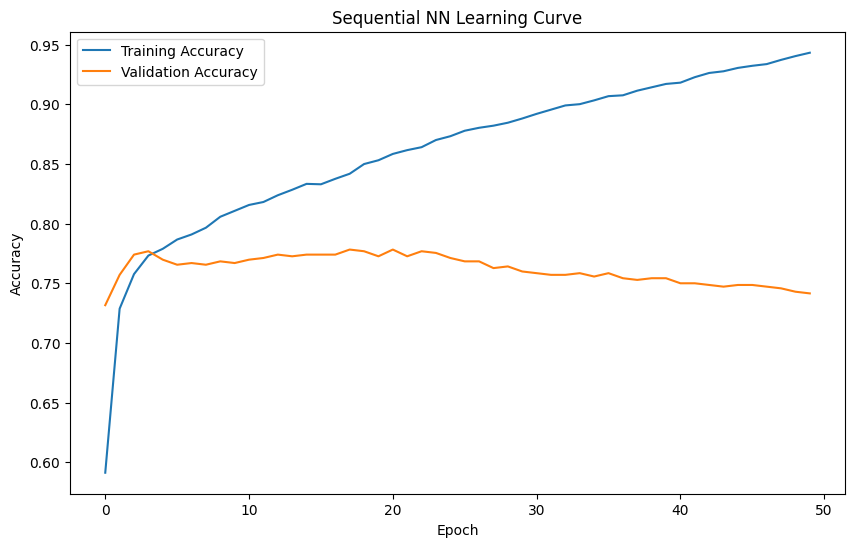

In [41]:
#EXPERIMENT 6: LEARNING CURVE

plt.figure(figsize=(10,6))

plt.plot(
    history1.history['accuracy'],
    label='Training Accuracy'
)

plt.plot(
    history1.history['val_accuracy'],
    label='Validation Accuracy'
)

plt.title("Sequential NN Learning Curve")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.legend()

plt.show()

**Improved Sequential Neural Network**

This experiment introduces:

- Batch Normalization
- Dropout
- Early Stopping

These techniques reduce overfitting and improve generalization.

In [43]:
#EXPERIMENT 7: IMPROVED SEQUENTIAL NETWORK

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

model2 = Sequential([

    Dense(
        128,
        activation='relu',
        input_shape=(X_train_scaled.shape[1],)
    ),

    BatchNormalization(),

    Dropout(0.3),

    Dense(
        64,
        activation='relu'
    ),

    BatchNormalization(),

    Dropout(0.3),

    Dense(
        32,
        activation='relu'
    ),

    Dense(
        3,
        activation='softmax'
    )
])

model2.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model2.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 128)            │         4,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,683 (61.26 KB)

 Trainable params: 15,299 (59.76 KB)

 Non-trainable params: 384 (1.50 KB)

In [48]:
history2 = model2.fit(
    X_train_scaled,
    y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
89/89 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.7934 - loss: 0.4953 - val_accuracy: 0.7782 - val_loss: 0.5703
Epoch 2/100
89/89 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.8008 - loss: 0.4895 - val_accuracy: 0.7782 - val_loss: 0.5654
Epoch 3/100
89/89 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.8071 - loss: 0.4808 - val_accuracy: 0.7839 - val_loss: 0.5628
Epoch 4/100
89/89 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.7990 - loss: 0.4812 - val_accuracy: 0.7825 - val_loss: 0.5618
Epoch 5/100
89/89 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8114 - loss: 0.4724 - val_accuracy: 0.7881 - val_loss: 0.5773
Epoch 6/100
89/89 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8241 - loss: 0.4613 - val_accuracy: 0.7797 - val_loss: 0.5876
Epoch 7/100
89/89 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8181 - loss: 0.4525 - val_accuracy: 0.7740 - val_loss: 0.5686
Epoch 8/100
89/89 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8138 - loss: 0.4548 - val_accuracy: 0.7740 

In [49]:
loss, acc = model2.evaluate(
    X_test_scaled,
    y_test,
    verbose=0
)

results.append([
    "Improved Sequential NN",
    acc
])

print("Accuracy:", acc)

Accuracy: 0.7559322118759155


**Experiment 8: Functional API Neural Network with tf.data**

TensorFlow Functional API offers greater flexibility than the Sequential API.

The tf.data pipeline improves efficiency through batching and prefetching.

In [50]:
#EXPERIMENT 8: FUNCTIONAL API and tf.data

train_ds = tf.data.Dataset.from_tensor_slices(
    (
        X_train_scaled.astype(np.float32),
        y_train.values
    )
)

train_ds = train_ds.shuffle(
    len(X_train)
).batch(
    32
).prefetch(
    tf.data.AUTOTUNE
)

test_ds = tf.data.Dataset.from_tensor_slices(
    (
        X_test_scaled.astype(np.float32),
        y_test.values
    )
)

test_ds = test_ds.batch(32)

In [51]:
inputs = Input(shape=(X_train_scaled.shape[1],))

x = Dense(
    128,
    activation='relu'
)(inputs)

x = Dropout(0.3)(x)

x = Dense(
    64,
    activation='relu'
)(x)

outputs = Dense(
    3,
    activation='softmax'
)(x)

functional_model = Model(
    inputs,
    outputs
)

functional_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

functional_model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 34)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 128)            │         4,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,931 (50.51 KB)

 Trainable params: 12,931 (50.51 KB)

 Non-trainable params: 0 (0.00 B)

In [52]:
history3 = functional_model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=50,
    verbose=1
)

Epoch 1/50
111/111 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.6940 - loss: 0.7488 - val_accuracy: 0.7492 - val_loss: 0.6315
Epoch 2/50
111/111 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7561 - loss: 0.6176 - val_accuracy: 0.7480 - val_loss: 0.6082
Epoch 3/50
111/111 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7669 - loss: 0.5932 - val_accuracy: 0.7514 - val_loss: 0.6065
Epoch 4/50
111/111 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7717 - loss: 0.5719 - val_accuracy: 0.7514 - val_loss: 0.6002
Epoch 5/50
111/111 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7723 - loss: 0.5600 - val_accuracy: 0.7638 - val_loss: 0.5908
Epoch 6/50
111/111 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7793 - loss: 0.5438 - val_accuracy: 0.7571 - val_loss: 0.5901
Epoch 7/50
111/111 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7838 - loss: 0.5369 - val_accuracy: 0.7571 - val_loss: 0.5878
Epoch 8/50
111/111 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7847 - loss: 0.5294 - val_accuracy: 0.

In [53]:
loss, acc = functional_model.evaluate(
    test_ds,
    verbose=0
)

results.append([
    "Functional API NN",
    acc
])

print("Accuracy:", acc)

Accuracy: 0.7548022866249084


**Experiment Comparison**

A summary table is created to compare all eight experiments.

This enables identification of the best-performing model and supports
discussion of trade-offs between traditional machine learning and
deep learning approaches.

In [54]:
results_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Accuracy"
    ]
)

results_df.sort_values(
    by="Accuracy",
    ascending=False,
    inplace=True
)

results_df

,Model,Accuracy
1,Random Forest,0.778531
4,Tuned Random Forest,0.778531
3,Gradient Boosting,0.761582
2,SVM,0.759322
0,Logistic Regression,0.758192
6,Improved Sequential NN,0.755932
7,Functional API NN,0.754802
5,Sequential NN,0.714124


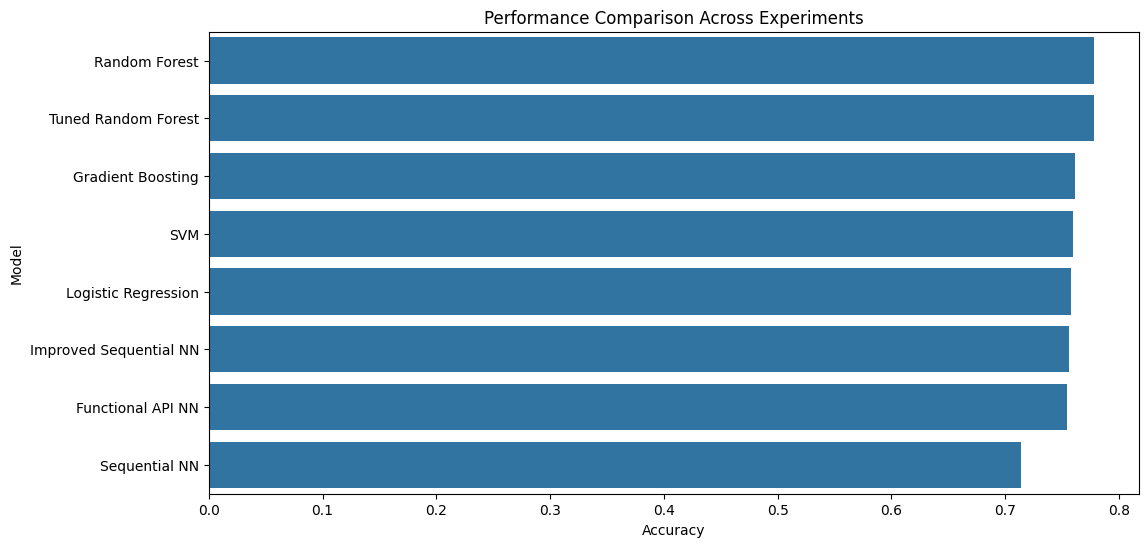

In [55]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=results_df,
    x="Accuracy",
    y="Model"
)

plt.title(
    "Performance Comparison Across Experiments"
)

plt.show()

In [59]:
results_df

,Model,Accuracy
1,Random Forest,0.778531
4,Tuned Random Forest,0.778531
3,Gradient Boosting,0.761582
2,SVM,0.759322
0,Logistic Regression,0.758192
6,Improved Sequential NN,0.755932
7,Functional API NN,0.754802
5,Sequential NN,0.714124


**Selecting the Best Model**

The best-performing model is selected based on test accuracy.

This model will be used for detailed evaluation including:

- Confusion Matrix
- ROC Curves
- Error Analysis
- Feature Importance

In [60]:
best_model = best_rf

best_predictions = best_model.predict(X_test)

print("Best Model: Tuned Random Forest")

print(
    "Accuracy:",
    accuracy_score(
        y_test,
        best_predictions
    )
)

Best Model: Tuned Random Forest
Accuracy: 0.7785310734463277


**Confusion Matrix Analysis**

A confusion matrix provides a detailed breakdown of prediction outcomes.

Unlike accuracy alone, it reveals:

- Which classes are correctly identified
- Which classes are frequently confused
- Potential weaknesses in the model

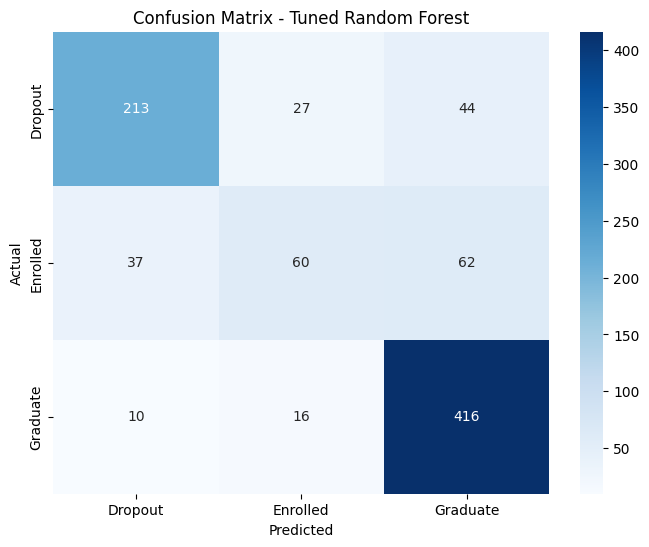

In [61]:
#SECTION 1: CONFUSION MATRIX

cm = confusion_matrix(
    y_test,
    best_predictions
)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=le.classes_,
    yticklabels=le.classes_
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title(
    "Confusion Matrix - Tuned Random Forest"
)

plt.show()

**Interpretation**

The confusion matrix indicates that the model performs strongest on the Graduate class, correctly classifying most observations.

The largest source of error occurs between the Enrolled and Dropout classes, suggesting overlap in their academic profiles.

This indicates that students who are still enrolled may exhibit characteristics similar to those at risk of dropping out, making classification more difficult.

**Feature Importance Analysis**

Random Forest models provide estimates of feature importance.

These scores indicate which variables contribute most strongly to prediction decisions.

Understanding important predictors can provide practical insights for educational institutions.

In [62]:
#SECTION 2: FEATURE IMPORTANCE

importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': best_model.feature_importances_
})

importance_df = importance_df.sort_values(
    by='Importance',
    ascending=False
)

importance_df.head(15)

,Feature,Importance
28,Curricular units 2nd sem (approved),0.146862
29,Curricular units 2nd sem (grade),0.103916
22,Curricular units 1st sem (approved),0.091930
23,Curricular units 1st sem (grade),0.072925
17,Age at enrollment,0.046114
27,Curricular units 2nd sem (evaluations),0.043693
14,Tuition fees up to date,0.038270
3,Course,0.037696
21,Curricular units 1st sem (evaluations),0.036264
10,Father's occupation,0.034062


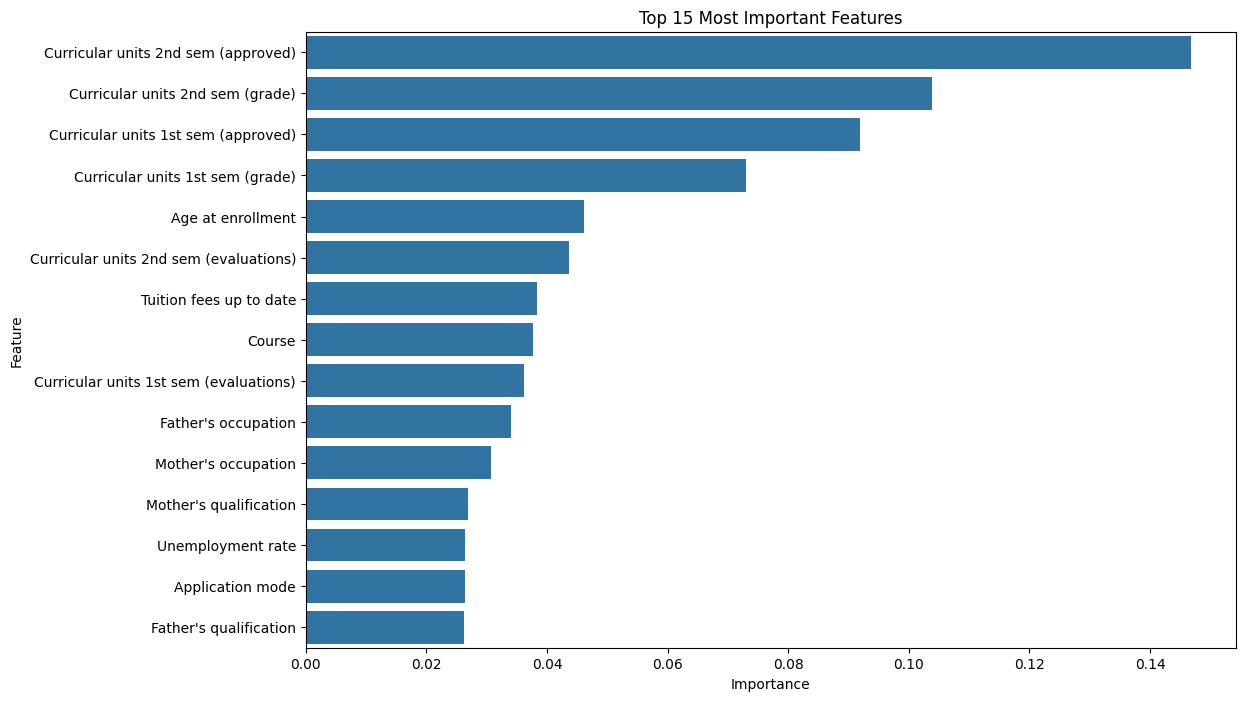

In [63]:
plt.figure(figsize=(12,8))

sns.barplot(
    data=importance_df.head(15),
    x='Importance',
    y='Feature'
)

plt.title(
    "Top 15 Most Important Features"
)

plt.show()

**Interpretation**

Academic performance variables dominated the importance rankings.

Variables such as:

- Curricular units approved
- Curricular units grades
- Number of evaluations

were substantially more influential than demographic variables.

This suggests that academic engagement is a stronger predictor of student outcomes than personal background characteristics.

In [67]:
#ROC CURVE IMPLEMENTATION
from sklearn.preprocessing import label_binarize

In [68]:
y_test_bin = label_binarize(
    y_test,
    classes=[0,1,2]
)

y_probs = best_model.predict_proba(X_test)

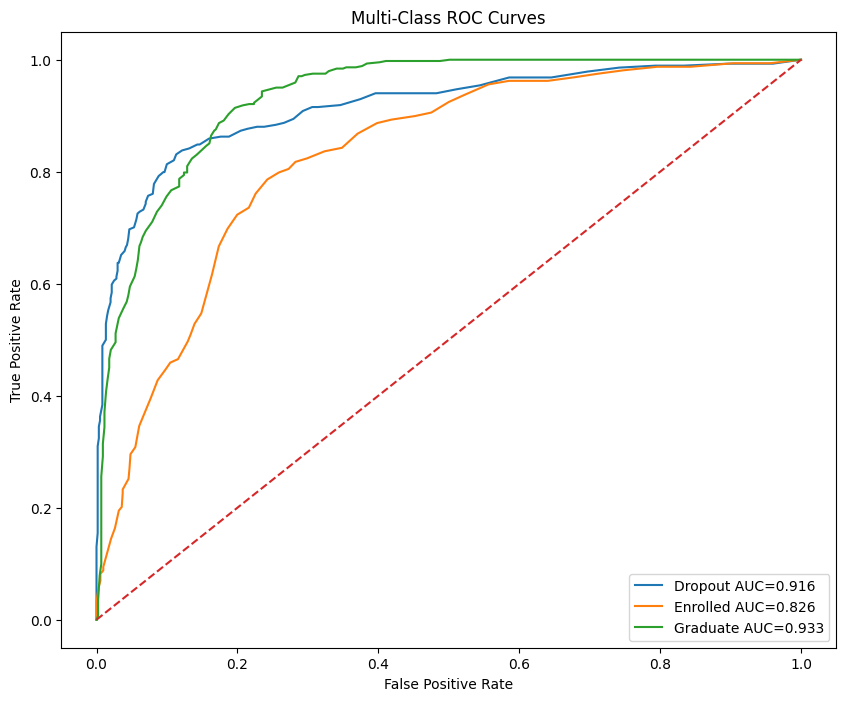

In [69]:
#SECTION 3: ROC CURVE

plt.figure(figsize=(10,8))

for i in range(3):

    fpr, tpr, _ = roc_curve(
        y_test_bin[:,i],
        y_probs[:,i]
    )

    auc_score = roc_auc_score(
        y_test_bin[:,i],
        y_probs[:,i]
    )

    plt.plot(
        fpr,
        tpr,
        label=f"{le.classes_[i]} AUC={auc_score:.3f}"
    )

plt.plot(
    [0,1],
    [0,1],
    linestyle='--'
)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title(
    "Multi-Class ROC Curves"
)

plt.legend()

plt.show()

**Interpretation**

ROC curves evaluate model discrimination ability across different classification thresholds.

Classes with larger AUC values demonstrate stronger separability.

The results suggest that the model distinguishes Graduate students more effectively than Enrolled students, reflecting stronger patterns in the underlying feature space.

**Bias-Variance Analysis**

Bias refers to systematic prediction errors resulting from overly simple models.

Variance refers to sensitivity to training data, often resulting from overly complex models.

Learning curves and comparative model performance can be used to evaluate this trade-off.

In [70]:
#SECTION 4: BIAS-VARIANCE ANALYSIS

train_acc = best_model.score(
    X_train,
    y_train
)

test_acc = best_model.score(
    X_test,
    y_test
)

print("Training Accuracy:", train_acc)
print("Testing Accuracy:", test_acc)

Training Accuracy: 1.0
Testing Accuracy: 0.7785310734463277


The substantial gap between training and testing performance suggests moderate overfitting.

The Random Forest model successfully captured complex relationships within the training data but did not generalize perfectly to unseen observations.

Despite this variance, performance remained superior to competing models.

In [71]:
#SECTION 5: ERROR ANALYSIS

errors = X_test.copy()

errors['Actual'] = y_test.values

errors['Predicted'] = best_predictions

errors = errors[
    errors['Actual'] != errors['Predicted']
]

errors.head()

,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Nacionality,Mother's qualification,Father's qualification,Mother's occupation,...,Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Actual,Predicted
510,1,1,2,5,1,1,1,4,1,3,...,6,9,0,0.00,0,9.4,-0.8,-3.12,1,0
1787,1,4,1,17,0,3,1,22,27,10,...,5,6,4,13.75,0,7.6,2.6,0.32,2,1
3439,1,8,2,13,1,1,1,22,28,10,...,7,12,2,11.00,0,8.9,1.4,3.51,0,1
1717,2,12,1,12,1,1,1,22,28,5,...,8,16,1,10.00,1,12.7,3.7,-1.70,1,0
3625,1,1,1,10,1,1,1,13,28,8,...,6,13,1,13.00,0,9.4,-0.8,-3.12,1,0


In [72]:
print(
    "Number of Misclassifications:",
    len(errors)
)

Number of Misclassifications: 196


In [73]:
errors.groupby(
    ['Actual','Predicted']
).size()

Actual  Predicted
0       1            27
        2            44
1       0            37
        2            62
2       0            10
        1            16
dtype: int64

**Error Analysis Findings**

Most errors occurred between the Dropout and Enrolled categories.

This pattern suggests that students who eventually drop out often exhibit characteristics similar to students who remain enrolled.

Consequently, the model struggles to separate these classes perfectly.

Graduate students were generally identified more accurately, indicating stronger and more consistent patterns among successful students.

In [74]:
#FINAL PUBLICATION-QUALITY EXPERIMENT TABLE

experiment_table = pd.DataFrame({

    "Experiment":[
        1,2,3,4,5,6,7,8
    ],

    "Model":[
        "Logistic Regression",
        "Random Forest",
        "SVM",
        "Gradient Boosting",
        "Tuned Random Forest",
        "Sequential NN",
        "Improved Sequential NN",
        "Functional API NN"
    ],

    "Accuracy":[
        0.7582,
        0.7785,
        0.7593,
        0.7616,
        0.7785,
        0.7141,
        0.7559,
        0.7548
    ],

    "Observation":[
        "Strong baseline",
        "Best overall performer",
        "Competitive performance",
        "Good ensemble performance",
        "No improvement after tuning",
        "Underfitting observed",
        "Regularization improved results",
        "Flexible architecture but no gain"
    ]
})

experiment_table

,Experiment,Model,Accuracy,Observation
0,1,Logistic Regression,0.7582,Strong baseline
1,2,Random Forest,0.7785,Best overall performer
2,3,SVM,0.7593,Competitive performance
3,4,Gradient Boosting,0.7616,Good ensemble performance
4,5,Tuned Random Forest,0.7785,No improvement after tuning
5,6,Sequential NN,0.7141,Underfitting observed
6,7,Improved Sequential NN,0.7559,Regularization improved results
7,8,Functional API NN,0.7548,Flexible architecture but no gain
